# Validation of our PV forecast pipeline

## Load Data from brazilian pv dataset

In [1]:
import pandas as pd
# using non-checked-in data from https://zenodo.org/records/21511487
path = '../data/real_pv/br-pvgen/'
metadata_df = pd.read_csv(path + "metadata.csv")
metadata_df['ps_id'] = metadata_df['id']
metadata_df = metadata_df.set_index(['ps_id'])
# pre-processed data generated in 01_prepare_data.ipynb
measurements_df = pd.read_parquet(path + "merged.parquet")
measurements_df['datetime'] = pd.to_datetime(measurements_df['datetime'])
measurements_df = measurements_df.set_index(['datetime', 'ps_id'])
print(measurements_df.info())
measurements_df

<class 'pandas.DataFrame'>
MultiIndex: 752909 entries, (Timestamp('2024-03-26 17:15:00+0000', tz='UTC'), 'PS_001') to (Timestamp('2025-06-09 19:30:00+0000', tz='UTC'), 'PS_051')
Data columns (total 3 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   total_active_power_w         752909 non-null  float64
 1   ambient_temperature_celsius  752909 non-null  float64
 2   ghi_irradiance_wm2           752909 non-null  float64
dtypes: float64(3)
memory usage: 21.1+ MB
None


,,total_active_power_w,ambient_temperature_celsius,ghi_irradiance_wm2
datetime,ps_id,,,
2024-03-26 17:15:00+00:00,PS_001,4.055110e+05,23.000000,96.539849
2024-03-26 17:30:00+00:00,PS_001,8.395200e+04,22.960714,53.623824
2024-03-26 17:45:00+00:00,PS_001,1.457120e+05,21.767193,14.290886
2024-03-26 18:00:00+00:00,PS_001,2.090670e+05,20.596816,33.510205
2024-03-26 18:15:00+00:00,PS_001,2.729760e+05,20.431653,50.439045
...,...,...,...,...
2025-06-09 18:30:00+00:00,PS_051,2.235609e+06,34.851252,358.443756
2025-06-09 18:45:00+00:00,PS_051,2.072260e+06,34.802081,300.378761
2025-06-09 19:00:00+00:00,PS_051,1.732663e+06,34.334583,245.017496


## Helper Functions

In [7]:
import datetime

def filter_for_ps_id(df, ps_id):
    return df[df.index.get_level_values("ps_id") == ps_id]
    
def filter_for_date(df, year,month=None,day=None):
    
    filter_mask = (df.index.get_level_values("datetime").year == year)
    if month is not None:
        filter_mask = filter_mask & (df.index.get_level_values("datetime").month == month)
    if day is not None:
        filter_mask = filter_mask & (df.index.get_level_values("datetime").day == day)
    return df[filter_mask]
    
# the metadata miss the actual panel size (only contain *module*-size and *panel* count)
# thus deriving panel size from nominal power and efficiency
def calc_area_m2(df, ps_id):
    df = df.loc[ps_id]
    # using standard units
    g_stc = 1000 # W/m2
    nominal_power_w = df['nominal_power_mw'] * 1000000
    efficiency = df['panel_efficiency_percentage']/100
    return nominal_power_w/(g_stc*efficiency)
    
# We only know the federal state of the asset. Define the state bounds for best location search
def get_bounding_rect_for_state(state):
    STATE_BOUNDS = {
        "SP": {
            "min_lat": -25.31,
            "max_lat": -19.78,
            "min_lon": -53.11,
            "max_lon": -44.16,
        },
        "RJ": {
            "min_lat": -23.37,
            "max_lat": -20.76,
            "min_lon": -44.89,
            "max_lon": -40.96,
        },
        "GO": {
            "min_lat": -19.50,
            "max_lat": -12.40,
            "min_lon": -53.25,
            "max_lon": -45.90,
        },
        "MG": {
            "min_lat": -22.92,
            "max_lat": -14.22,
            "min_lon": -51.05,
            "max_lon": -39.85,
        },
        "BA": {
            "min_lat": -18.35,
            "max_lat": -8.53,
            "min_lon": -46.62,
            "max_lon": -37.35,
        },
        "PR": {
            "min_lat": -26.72,
            "max_lat": -22.52,
            "min_lon": -54.62,
            "max_lon": -48.02,
        },
    }
    return STATE_BOUNDS[state]["min_lat"],STATE_BOUNDS[state]["max_lat"],STATE_BOUNDS[state]["min_lon"],STATE_BOUNDS[state]["max_lon"]

def get_bounding_rect_for_ps_id(df, ps_id):
    df = filter_for_ps_id(df, ps_id)
    return get_bounding_rect_for_state(df['brazil_federative_unit'].iloc[0])

print(calc_area_m2(metadata_df, 'PS_001'))
print(get_bounding_rect_for_ps_id(metadata_df, 'PS_001'))

measurements_df = filter_for_date(measurements_df, 2024)

24154.589371980677
(-25.31, -19.78, -53.11, -44.16)


## Test Visualization

<Axes: xlabel='datetime', ylabel='total_active_power_w'>

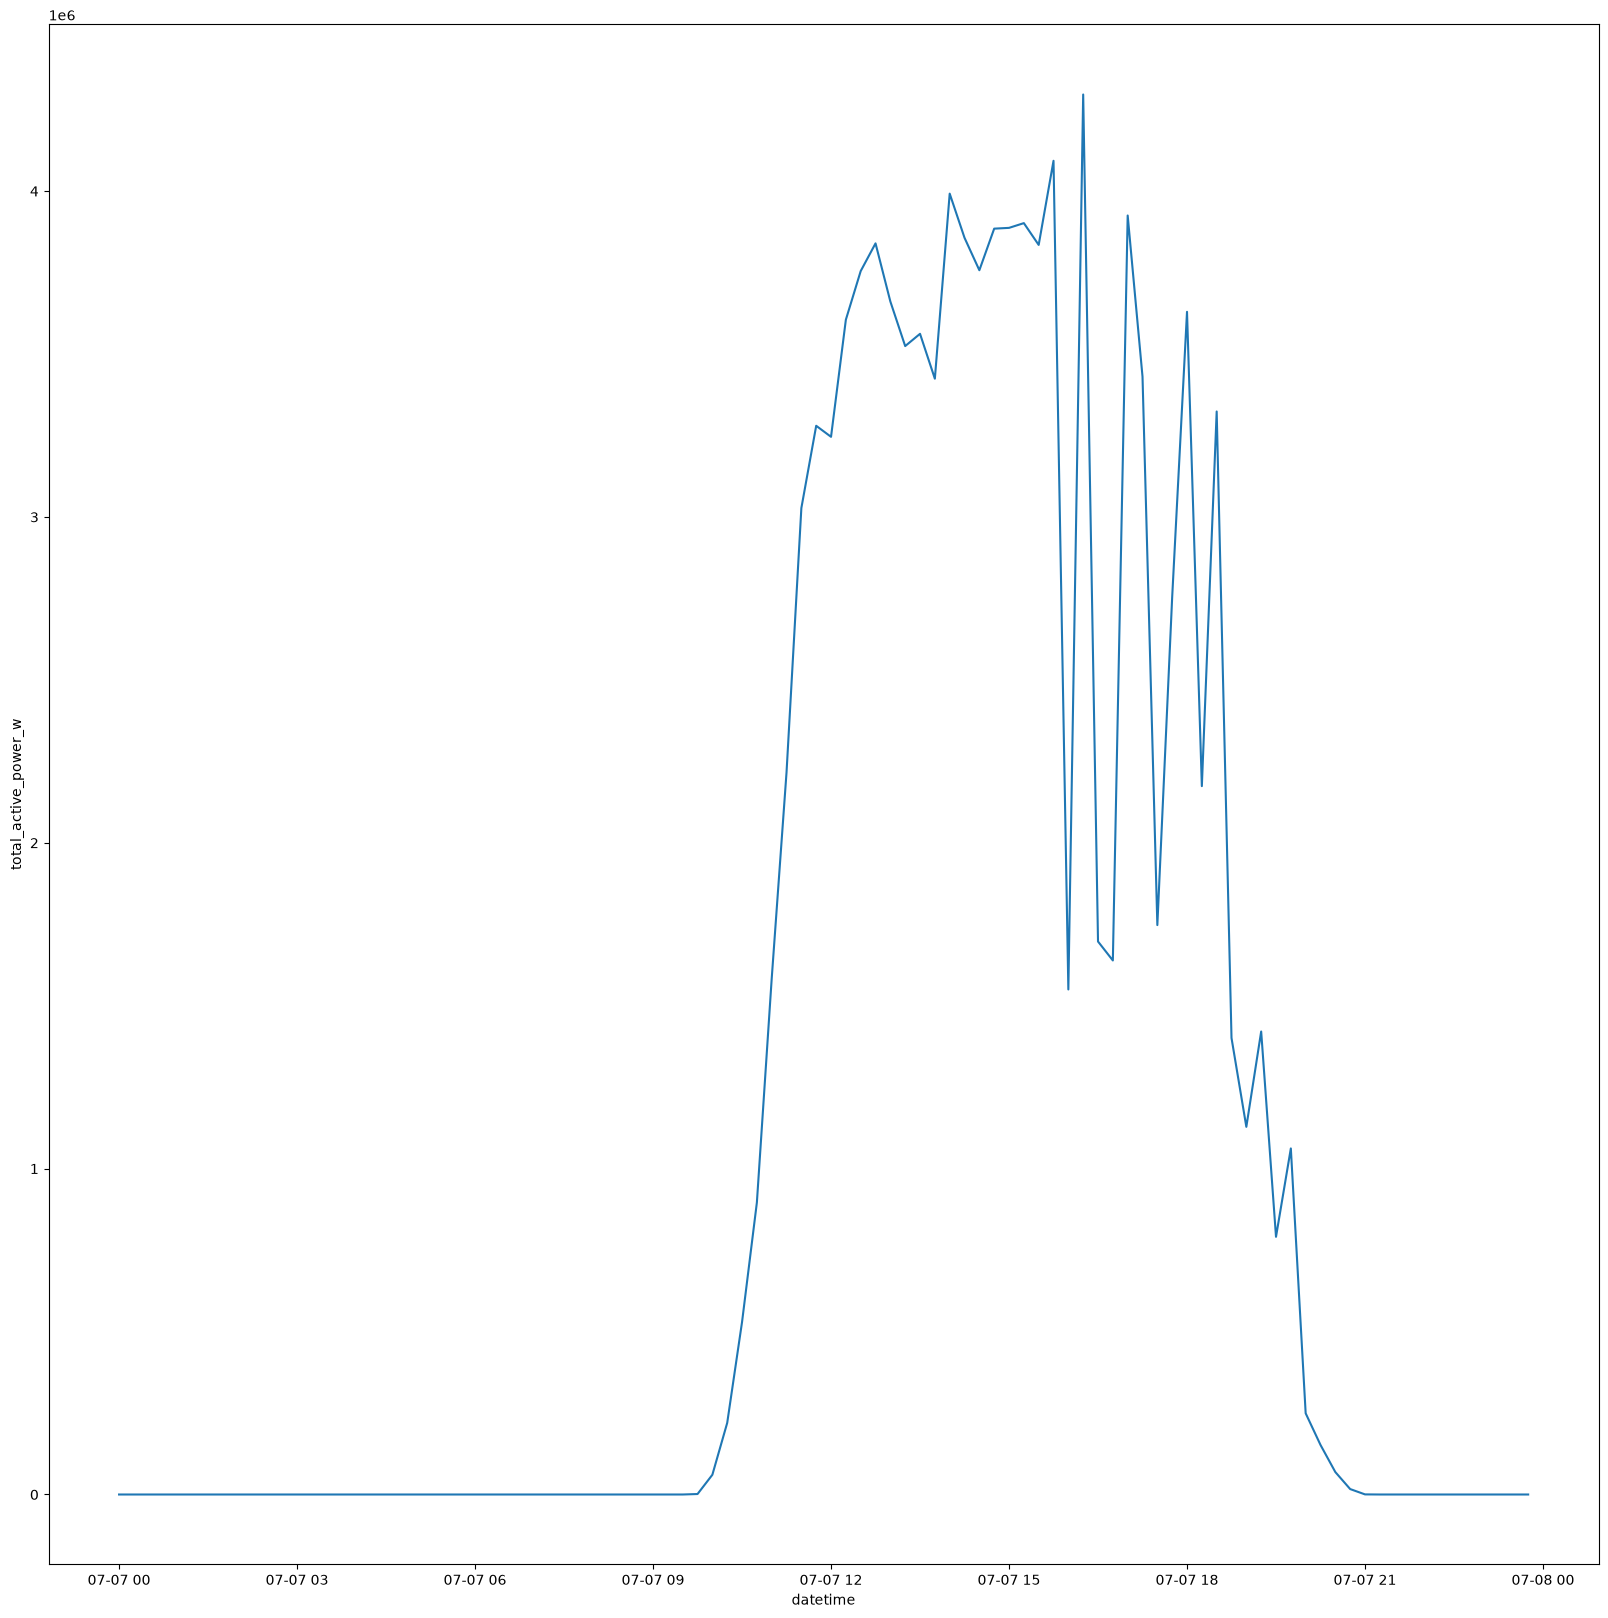

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_001'), 2024,7,7), x="datetime", y="total_active_power_w")


## Preparing Validation
### Fetching Weather Data from API
#### Build clients and request

In [4]:
from app.weather.open_meteo import OpenMeteoProvider
from app.weather.adapters.default import DefaultWeatherAdapter
from app.weather.open_meteo_mapping import OPEN_METEO_VARIABLES
from app.weather.resolver import WeatherLocationResolver
from app.weather.request import WeatherForecastRequest
from app.weather.result import WeatherForecastResult
from app.forecasting.enums import ForecastMetric
from app.weather.providers.open_meteo.client import Client
from app.weather.location import WeatherLocation

from datetime import timezone, datetime, timedelta

# configuring open meteo client to get historically correct data
api_url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
provider = OpenMeteoProvider(Client(api_url))

resolver = WeatherLocationResolver(
        grid_size=0.1
    )

adapter = DefaultWeatherAdapter(OPEN_METEO_VARIABLES, resolver)

# mimicking WeatherService
def get_forecast(request: WeatherForecastRequest) -> WeatherForecastResult:
    provider_result = (
        provider.get_forecast(
            request
        )
    )
    return adapter.adapt(
        provider_result,
        request
    )

request_variables = [
        ForecastMetric.WIND_SPEED,
        ForecastMetric.CLOUD_COVER,
        ForecastMetric.TEMPERATURE,
        ForecastMetric.GLOBAL_SOLAR_IRRADIANCE,
        ForecastMetric.DIRECT_NORMAL_IRRADIANCE,
        ForecastMetric.DIFFUSE_IRRADIANCE
    ]





#### Testing request 

In [5]:
start_date = datetime.now(timezone.utc) - timedelta(seconds=365*24*60*60)

request = WeatherForecastRequest(
        start=start_date,
        end=start_date + timedelta(days=1),
        resolution=timedelta(minutes=15),
        locations=[WeatherLocation(52,10)],
        variables=request_variables
    )
print(get_forecast(request))

WeatherForecastResult(provider='open_meteo', model='best_match', forecasts=[WeatherLocationForecast(location=WeatherLocation(latitude=52.0, longitude=10.0), run=ForecastRun(start=datetime.datetime(2025, 8, 28, 0, 0, tzinfo=datetime.timezone.utc), resolution=datetime.timedelta(seconds=900), slots=97), series=[ForecastSeries(metric=<ForecastMetric.WIND_SPEED: 'wind_speed'>, values=[ForecastValue(p50=14.685175895690918, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=13.627795219421387, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=12.496719360351562, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=11.440978050231934, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=11.01388168334961, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=11.304228782653809, p05=None, p95=None, 

#### Adding forecast data: Actual request

In [44]:
import time
forecasts = {}

for ps_id in measurements_df.index.get_level_values("ps_id").unique():
    filtered_measurement = filter_for_ps_id(measurements_df, ps_id)
    if len(filtered_measurement) == 0:
        continue
        
    area = calc_area_m2(metadata_df, ps_id)
    # get forecast for whole grid in state. used to estimate actual location of asset 
    min_lat, max_lat, min_lon, max_lon = get_bounding_rect_for_ps_id(metadata_df, ps_id)
    
    # create 4x4 grid
    grid_count = 4
    locations = []
    for i_lat in range(0, grid_count):
        lat = min_lat + i_lat*(max_lat - min_lat)/(grid_count - 1)
        for i_lon in range(0, grid_count):
            lon = min_lon + i_lon*(max_lon - min_lon)/(grid_count - 1)
            locations.append(WeatherLocation(lat,lon))

    # request for all grid locations and for all dates in measurement data
    start_date = filtered_measurement.index[0][0]
    end_date = filtered_measurement.index[len(filtered_measurement)-1][0]
    request = WeatherForecastRequest(
        start=start_date,
        end=end_date,
        resolution=timedelta(minutes=15),
        locations=locations,
        variables=request_variables
    )
    # save for later use 
    forecasts[ps_id] = get_forecast(request)
    # simple protection against api request limit
    print("Successfully requested weather for ps_id ", ps_id, (min_lat, max_lat, min_lon, max_lon))
    time.sleep(15)


    
        
    

Successfully requested weather for ps_id  PS_001 (-25.31, -19.78, -53.11, -44.16)
Successfully requested weather for ps_id  PS_002 (-23.37, -20.76, -44.89, -40.96)
Successfully requested weather for ps_id  PS_003 (-23.37, -20.76, -44.89, -40.96)
Successfully requested weather for ps_id  PS_004 (-25.31, -19.78, -53.11, -44.16)
Successfully requested weather for ps_id  PS_005 (-19.5, -12.4, -53.25, -45.9)
Successfully requested weather for ps_id  PS_006 (-22.92, -14.22, -51.05, -39.85)
Successfully requested weather for ps_id  PS_007 (-23.37, -20.76, -44.89, -40.96)
Successfully requested weather for ps_id  PS_008 (-25.31, -19.78, -53.11, -44.16)
Successfully requested weather for ps_id  PS_009 (-25.31, -19.78, -53.11, -44.16)
Successfully requested weather for ps_id  PS_010 (-25.31, -19.78, -53.11, -44.16)
Successfully requested weather for ps_id  PS_011 (-25.31, -19.78, -53.11, -44.16)
Successfully requested weather for ps_id  PS_012 (-19.5, -12.4, -53.25, -45.9)
Successfully requested

#### Check samples of forecast results

In [45]:
# check for plausible result data
print(forecasts['PS_001'].forecasts[0].location)
print(forecasts['PS_001'].forecasts[0].run)
print(forecasts['PS_001'].forecasts[0].series[0].values[0:20])
print(forecasts['PS_001'].forecasts[0].series[1].metric)
print(forecasts['PS_001'].forecasts[4].location)
print(forecasts['PS_001'].forecasts[5].location)
print(forecasts.keys())
print(len(metadata_df))



WeatherLocation(latitude=-25.3, longitude=-53.1)
ForecastRun(start=datetime.datetime(2024, 3, 26, 0, 0, tzinfo=datetime.timezone.utc), resolution=datetime.timedelta(seconds=900), slots=26907)
[ForecastValue(p50=5.116561412811279, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=5.9834771156311035, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=7.309418678283691, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=8.686748504638672, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=9.387651443481445, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=9.387651443481445, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=8.686748504638672, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=7.956732749

In [13]:
print(measurements_df.index.get_level_values("ps_id").unique())

Index(['PS_001', 'PS_002', 'PS_003', 'PS_004', 'PS_005', 'PS_006', 'PS_007',
       'PS_008', 'PS_009', 'PS_010', 'PS_011', 'PS_012', 'PS_013', 'PS_014',
       'PS_015', 'PS_016', 'PS_028', 'PS_033', 'PS_034', 'PS_035', 'PS_036',
       'PS_037', 'PS_038', 'PS_039', 'PS_040', 'PS_041'],
      dtype='object', name='ps_id')


#### Build dataframe from forecasts

In [46]:
df_rows = {}
locations = {}
for ps_id, forecast_result in forecasts.items():
    locations[ps_id] = {}
    for lid, forecast in enumerate(forecast_result.forecasts):
        start = forecast.run.start
        resolution = forecast.run.resolution
        # save actual locations of forecast result
        locations[ps_id][lid] = forecast.location

        # save all values and series in pre-dataframe dict
        for sid, series in enumerate(forecast.series):
            column_name = series.metric + '_' + str(lid)
            time = start
            if column_name not in df_rows.keys():
                    df_rows[column_name] = {}
            for value in series.values:
                index = (time, ps_id)
                df_rows[column_name][index] = value.p50
                time += resolution
                
                

df = pd.DataFrame(df_rows)
# important for easy join
df.index = df.index.set_names(["datetime", "ps_id"])
print(df['cloud_cover_0'])

df.to_parquet(path + "weather_forecasts_multi_location.parquet")


                
        

datetime                   ps_id 
2024-03-26 00:00:00+00:00  PS_001     1.00
2024-03-26 00:15:00+00:00  PS_001     0.75
2024-03-26 00:30:00+00:00  PS_001     0.50
2024-03-26 00:45:00+00:00  PS_001     0.25
2024-03-26 01:00:00+00:00  PS_001     0.00
                                     ...  
2024-12-22 22:45:00+00:00  PS_041    77.50
2024-12-22 23:00:00+00:00  PS_041    70.00
2024-12-22 23:15:00+00:00  PS_041    70.00
2024-12-22 23:30:00+00:00  PS_041    70.00
2024-12-22 23:45:00+00:00  PS_041    70.00
Name: cloud_cover_0, Length: 361248, dtype: float64


#### Test structure and join

In [15]:
test_measurements_df = filter_for_ps_id(measurements_df, 'PS_001')
test_measurements_df = filter_for_ps_id(measurements_df, 'PS_001').join(df)
test_measurements_df


,,total_active_power_w,ambient_temperature_celsius,ghi_irradiance_wm2,wind_speed_0,temperature_0,global_solar_irradiance_0,direct_normal_irradiance_0,diffuse_irradiance_0,cloud_cover_0,wind_speed_1,...,global_solar_irradiance_14,direct_normal_irradiance_14,diffuse_irradiance_14,cloud_cover_14,wind_speed_15,temperature_15,global_solar_irradiance_15,direct_normal_irradiance_15,diffuse_irradiance_15,cloud_cover_15
datetime,ps_id,,,,,,,,,,,,,,,,,,,,,
2024-03-26 17:15:00+00:00,PS_001,405511.0,23.000000,96.539849,3.826853,28.900000,773.0,817.755981,106.0,19.00,3.640275,...,206.0,6.163782,201.0,100.00,4.610250,21.400000,190.0,13.977434,179.0,100.0
2024-03-26 17:30:00+00:00,PS_001,83952.0,22.960714,53.623824,3.457687,28.950001,744.0,811.314392,102.0,19.00,3.462369,...,185.0,3.845487,182.0,100.00,4.582052,21.450001,203.0,19.914339,188.0,100.0
2024-03-26 17:45:00+00:00,PS_001,145712.0,21.767193,14.290886,3.462369,28.950001,714.0,806.813110,98.0,19.00,3.438895,...,169.0,2.682140,167.0,100.00,4.394360,21.500000,203.0,22.340818,187.0,100.0
2024-03-26 18:00:00+00:00,PS_001,209067.0,20.596816,33.510205,3.415260,28.950001,684.0,804.279358,95.0,19.00,3.617955,...,155.0,4.237581,152.0,100.00,4.510787,21.500000,196.0,22.189575,181.0,100.0
2024-03-26 18:15:00+00:00,PS_001,272976.0,20.431653,50.439045,3.640275,28.900000,651.0,799.489990,93.0,19.25,3.797104,...,142.0,5.995842,138.0,100.00,4.829907,21.500000,183.0,18.961905,171.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00+00:00,PS_001,0.0,26.471496,-2.315878,4.693825,24.100000,0.0,0.000000,0.0,24.00,8.827344,...,0.0,0.000000,0.0,19.25,5.649248,21.100000,0.0,0.000000,0.0,100.0
2024-12-31 23:00:00+00:00,PS_001,0.0,25.944618,-2.577081,4.873315,23.750000,0.0,0.000000,0.0,13.00,8.049845,...,0.0,0.000000,0.0,17.00,5.815978,20.950001,0.0,0.000000,0.0,100.0
2024-12-31 23:15:00+00:00,PS_001,0.0,25.573536,-2.645917,5.447788,23.500000,0.0,0.000000,0.0,13.00,4.610250,...,0.0,0.000000,0.0,17.00,5.474486,20.850000,0.0,0.000000,0.0,100.0


#### Find out more precise locations via correlations of weather variables
The Metadata file only tells us the state. We need to find a more precise location. My approach is via correlation of API weather data at a known location on a search grid and actual weather data at the unknown asset location.

In [54]:
import numpy as np

# ... where correlation data will be saved for each asset
irradiance_corr = {}
temperature_corr = {}
# more important: best locations. THey tell us which weather data to use for our prediction
best_locations = {}
best_loc_indices = {}

# re-read measurements to reset to original
orig_measurements_df = pd.read_parquet(path + "merged.parquet")
orig_measurements_df['datetime'] = pd.to_datetime(orig_measurements_df['datetime'])
orig_measurements_df = orig_measurements_df.set_index(['datetime', 'ps_id'])

for ps_id in forecasts.keys():
    test_locations = locations[ps_id]
    test_measurements_df = filter_for_ps_id(orig_measurements_df, ps_id).join(df)
    
    irradiance_col_names = ['ghi_irradiance_wm2']
    temperature_col_names = ['ambient_temperature_celsius']
    for lid, location in enumerate(test_locations):
        irradiance_col_names.append('global_solar_irradiance_' + str(lid))
        temperature_col_names.append('temperature_' + str(lid))
    test_irradiance_df = test_measurements_df[irradiance_col_names]
    test_temperature_df = test_measurements_df[temperature_col_names]
    
    irradiance_corr[ps_id] = test_irradiance_df.corr()
    temperature_corr[ps_id] = test_temperature_df.corr()
    # avoid finding out correlation with same column is highest ;) 
    irradiance_corr[ps_id].loc['ghi_irradiance_wm2', 'ghi_irradiance_wm2'] = 0
    temperature_corr[ps_id].loc['ambient_temperature_celsius', 'ambient_temperature_celsius'] = 0
    #display(irradiance_corr[ps_id])
    #print(irradiance_corr[ps_id]['ghi_irradiance_wm2'].idxmax())
    #display(temperature_corr[ps_id])
    #print(temperature_corr[ps_id]['ambient_temperature_celsius'].idxmax())
    best_index = str(irradiance_corr[ps_id]['ghi_irradiance_wm2'].idxmax()).split('_')[-1]
    best_loc_indices[ps_id] = best_index
    best_locations[ps_id] = test_locations[int(best_index)]

print("Best locations", best_locations)

Best locations {'PS_001': WeatherLocation(latitude=-21.6, longitude=-47.2), 'PS_002': WeatherLocation(latitude=-22.5, longitude=-43.6), 'PS_003': WeatherLocation(latitude=-22.5, longitude=-43.6), 'PS_004': WeatherLocation(latitude=-23.400000000000002, longitude=-47.1), 'PS_005': WeatherLocation(latitude=-17.1, longitude=-48.300000000000004), 'PS_006': WeatherLocation(latitude=-22.900000000000002, longitude=-47.300000000000004), 'PS_007': WeatherLocation(latitude=-22.5, longitude=-43.6), 'PS_008': WeatherLocation(latitude=-21.6, longitude=-50.1), 'PS_009': WeatherLocation(latitude=-21.6, longitude=-50.1), 'PS_010': WeatherLocation(latitude=-23.400000000000002, longitude=-47.1), 'PS_011': WeatherLocation(latitude=-21.6, longitude=-50.1), 'PS_012': WeatherLocation(latitude=-17.1, longitude=-53.300000000000004), 'PS_013': WeatherLocation(latitude=-21.6, longitude=-47.2), 'PS_014': WeatherLocation(latitude=-25.3, longitude=-48.2), 'PS_015': WeatherLocation(latitude=-17.1, longitude=-47.3000

#### Creating PvForecast Calculator

In [49]:
# Composition of Forecast calculator

from app.asset_forecast.calculators.pv_power_calculator import (
    PvPowerCalculator,
)

from app.asset_forecast.calculators.plane_of_array_calculator import (
    PlaneOfArrayCalculator,
)

from app.asset_forecast.calculators.solar_geometry_calculator import (
    SolarGeometryCalculator,
)
from app.asset_forecast.calculators.pv_forecast_calculator import (
    PvForecastCalculator,
)

calculator = PvForecastCalculator(
        solar_geometry_calculator=(
            SolarGeometryCalculator()
        ),
        plane_of_array_calculator=(
            PlaneOfArrayCalculator()
        ),
        pv_power_calculator=(
            PvPowerCalculator()
        ),
    )

#### Generating POWER forecast

In [56]:
from app.asset_forecast.domain.pv_forecast import (
    PvForecastInput,
    PvForecastResult,
)

from app.asset_forecast.domain.panel_geometry import PanelGeometry
from app.asset_forecast.domain.pv_configuration import PvConfiguration

# elevation_deg: float
# azimuth_deg: float
forecast_rows = {
    'calculated_poa_radiance': {},
    'calculated_active_power_w': {},
    'solar_position_ele': {},
    'solar_position_azi': {},
    'is_dawn': {}
}
measurements_df = orig_measurements_df.join(df) 
for ps_id in forecasts.keys():
    test_measurements_df = filter_for_ps_id(measurements_df, ps_id)
    location = best_locations[ps_id]
    # To find the corresponding column
    loc_index = best_loc_indices[ps_id]
    area = calc_area_m2(metadata_df, ps_id)
    efficiency = metadata_df.loc[ps_id]['panel_efficiency_percentage']/100
    # best guess: pointing to sun over equator
    tilt = abs(location.latitude)
    # best guess: pointing north on sothern hemisphere
    azimuth = 0
    
    # define column names that contain weather data of our derived best location
    direct_irradiance_colname = 'direct_normal_irradiance_' + loc_index
    diffuse_colname = 'diffuse_irradiance_' + loc_index
    
    panel_geometry = PanelGeometry(tilt,azimuth)
    pv_configuration = PvConfiguration(area,efficiency)
    for index, row in test_measurements_df.iterrows():
        forecast_input = PvForecastInput(
            timestamp=index[0],
            latitude=location.latitude,
            longitude=location.longitude,
            direct_normal_irradiance=row[direct_irradiance_colname],
            diffuse_radiation=row[diffuse_colname],
            panel_geometry=panel_geometry,
            pv_configuration=pv_configuration
        )
        forecast_result = calculator.calculate(forecast_input)
        forecast_rows['calculated_poa_radiance'][index] = forecast_result.plane_of_array_irradiance
        forecast_rows['calculated_active_power_w'][index] = forecast_result.active_power_kw * 1000
        # Store solar position for error debugging
        forecast_rows['solar_position_ele'][index] = forecast_result.solar_position.elevation_deg
        forecast_rows['solar_position_azi'][index] = forecast_result.solar_position.azimuth_deg
        forecast_rows['is_dawn'][index] = max(0, 1 - forecast_result.solar_position.elevation_deg/25)

forecast_df = pd.DataFrame(forecast_rows)

    
    

In [60]:
# join forecast and measurements
forecast_df.index = forecast_df.index.set_names(['datetime', 'ps_id'])
forecast_df.to_parquet(path + "asset_forecast.parquet")
# measurements_df = measurements_df.join(forecast_df)


/tmp/ipykernel_1826520/266628853.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


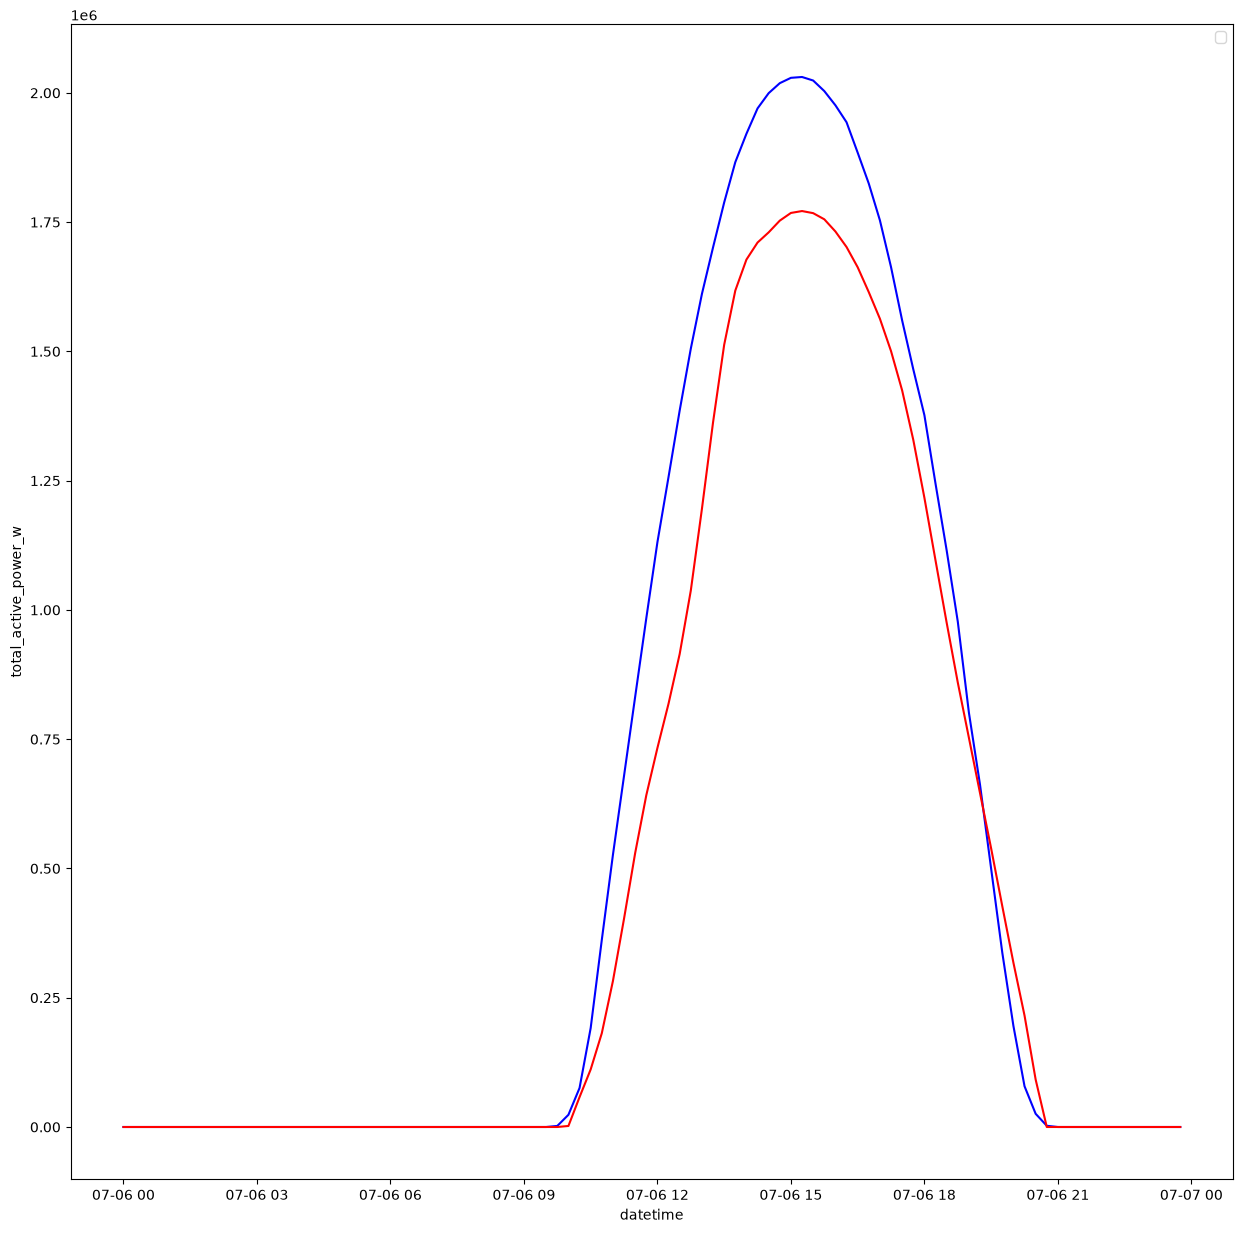

In [61]:
plt.figure(figsize=(15,15))
sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_004'), 2024,7,6), x="datetime", y="total_active_power_w", color="b")
sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_004'), 2024,7,6), x="datetime", y="calculated_active_power_w", color="r")
plt.legend()
#plt.figure(figsize=(15,15))
#sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_001'), 2024,7), x="datetime", y=["total_active_power_w", "calculated_poa_radiance"])

### First Result

We can see that our forecast is in realistic dimensions. There are some systematic effects that can be used for improvement: Rainy/Cloudy days are systematically over-predicted. We need to adjust our diffuse radiation model. Tracker/Fixed systems are counter-intuitively predicted: We overrate trackers (PS_001, PS_005) (while not assuming their better alignment with the sun in the prediction) and underrated fixed (PS_002 - PS_004) systems. Also, we know these systems are bifacial, which is not reflected in our model yet. 

## Quantitative Validation

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def validation_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    
    relative_mae = mae / y_true.mean()
    return mae, mse, rmse, relative_mae

def print_validation_values(mae, mse, rmse, relative_mae):
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"relative MAE: {relative_mae:.4f}")






In [64]:
result_df = measurements_df.dropna(subset=['total_active_power_w','calculated_active_power_w'])
result_df = result_df[result_df.index.get_level_values("ps_id") != "PS_016"] # 94% error can be considered an outlier, when rest is 25-58%
result_df = result_df[result_df.index.get_level_values("ps_id") != "PS_041"] # 1200% error can be considered an outlier, when rest is 25-58%
result_df = result_df[result_df.index.get_level_values("ps_id") != "PS_033"] # 72% error can be considered an outlier, when rest is 25-58%

y_true = result_df['total_active_power_w']
y_pred = result_df['calculated_active_power_w']
print('Total metric')
print_validation_values(*validation_metrics(y_true, y_pred))

r_mae_per_psid = {}
# metric for different assets
for ps_id in result_df.index.get_level_values("ps_id").unique():
    test_subset = filter_for_ps_id(result_df, ps_id)
    y_true = test_subset['total_active_power_w']
    y_pred = test_subset['calculated_active_power_w']
    print("metrics for ps_id", ps_id)
    metrics = validation_metrics(y_true, y_pred)
    print_validation_values(*metrics)
    print("\n")
    r_mae_per_psid[ps_id] = metrics[3]

Total metric
MAE: 212559.6181
MSE: 242266185309.9201
RMSE: 492205.4300
relative MAE: 0.3666
metrics for ps_id PS_001
MAE: 445103.6851
MSE: 804653129432.8949
RMSE: 897024.5980
relative MAE: 0.3839


metrics for ps_id PS_002
MAE: 60968.8216
MSE: 16562891360.8227
RMSE: 128696.8972
relative MAE: 0.2607


metrics for ps_id PS_003
MAE: 61184.9127
MSE: 16848166882.4723
RMSE: 129800.4888
relative MAE: 0.2693


metrics for ps_id PS_004
MAE: 131841.5197
MSE: 67527769952.7956
RMSE: 259861.0589
relative MAE: 0.2538


metrics for ps_id PS_005
MAE: 163356.0476
MSE: 114333235464.9013
RMSE: 338131.9794
relative MAE: 0.3561


metrics for ps_id PS_006
MAE: 326751.7668
MSE: 387164784996.5193
RMSE: 622225.6705
relative MAE: 0.3357


metrics for ps_id PS_007
MAE: 76681.7498
MSE: 24150189956.5246
RMSE: 155403.3139
relative MAE: 0.3286


metrics for ps_id PS_008
MAE: 317620.4501
MSE: 376190995575.0557
RMSE: 613344.1086
relative MAE: 0.2911


metrics for ps_id PS_009
MAE: 91509.8556
MSE: 33556128171.3485
RMSE

## Error analysis

We are starting with a quick error analysis of error per asset and the correlation with the asset's meta data.

In [65]:
r_mae_per_psid = dict(sorted(r_mae_per_psid.items(), key=lambda item: item[1], reverse=True))
print(r_mae_per_psid)
metadata_df['r_mae'] = metadata_df.index.map(r_mae_per_psid)
# Quick check of numeric values
error_df = metadata_df.select_dtypes(include=["number"])


display(error_df.corr()['r_mae'])

{'PS_012': np.float64(0.582882418671706), 'PS_010': np.float64(0.5781079155472038), 'PS_014': np.float64(0.49650035829312583), 'PS_040': np.float64(0.4761644245511918), 'PS_039': np.float64(0.46069855184199693), 'PS_034': np.float64(0.4202913652126235), 'PS_011': np.float64(0.41194760161630595), 'PS_037': np.float64(0.41061742095866016), 'PS_035': np.float64(0.39017360933418105), 'PS_036': np.float64(0.38917830629957667), 'PS_001': np.float64(0.3839473331227764), 'PS_038': np.float64(0.3638836147004369), 'PS_005': np.float64(0.35614307453519567), 'PS_028': np.float64(0.3547182210827999), 'PS_009': np.float64(0.3484204465464216), 'PS_013': np.float64(0.3468680945202672), 'PS_006': np.float64(0.335667784070875), 'PS_007': np.float64(0.32862996546525813), 'PS_008': np.float64(0.2910730216014689), 'PS_015': np.float64(0.2828172984732374), 'PS_003': np.float64(0.26931125100001924), 'PS_002': np.float64(0.2607154806275058), 'PS_004': np.float64(0.2537753401382327)}


nominal_power_mw                 0.401001
number_of_panels                 0.335279
panel_area_mm2                   0.354043
panel_bifaciality_coefficient         NaN
panel_efficiency_percentage      0.124867
panel_temperature_coefficient    0.092731
r_mae                            1.000000
Name: r_mae, dtype: float64

### Interpretation of first analysis: 

correlation coefficients for r_mae per asset and asset's meta data: 
| variable  | correlation with r_mae  |
|---|---|
|nominal_power_mw|                 0.475181|
|number_of_panels |                0.400294|
|panel_area_mm2|                   0.411271|
|panel_efficiency_percentage|      0.413322|
|panel_temperature_coefficient|    0.331299|

Relative errors are strongly correlated with metadata. This is a hint for a systematic error. 
First ideas of possible explanation: 
- Size/capacity related parameters are very strongly correlated. That might indicate e.g. that downtimes lead to a bigger over-estimation of our still naive physical model. Or big assets need to be curtailed more often. Also shadowing at dusk and dawn might effect bigger assets relatively more than smaller ones
- Temperature coefficient: The bigger the coefficient, the higher the influence of the temperature, the bigger the error when we do not reflect temperature in our model
- efficiency: might have to do with curtailment. Curtailment is not reflected in our model, and the higher the efficiency, the bigger the over-estimation during curtailment. But also another effect might be considered: Efficiency and nominal power are the main estimators for our asset's total panel area. Which might lead to a constant error factor in our prediction.

Results must be taken with a grain of salt because we have a small metadata set here, but coefficients are big enough to indicate statistically significant relations between variables and error.

Conclusion/ToDos: 
- Check curtailment/dusk/dawn, check temporal error distribution: When is the error highest? Is it a constant factor or time dependent? Do the results of these investigations correlate with asset parameters?
- Implement temperature dependence
- check non numerical metadata for correlation with the error
- check error sign: Manual checks have already shown a correlation of mean error polarity with the parameter "structure_type" (Fixed/Tracker)